# IDS Stage 1 - Adapted for nDPI CSV Format
Détection d'anomalies sur données de flux réseau nDPI

In [202]:
# Import relevant modules
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import pickle
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import metrics, tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.feature_selection import RFE
import itertools

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Settings
pd.set_option('display.max_columns', None)
np.set_printoptions(threshold=1000)
np.set_printoptions(precision=3)
sns.set(style="darkgrid")
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

## 1. LOAD DATA

In [203]:
# Chemins vers vos datasets
TRAIN_PATH = "data/vertx_flows_NormalTraffic_7_881.csv"
TEST_PATH = "data/vertx_flows_test2.csv"  # ou un autre fichier test

print("📥 Chargement des données...")
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print(f"✅ Train: {train.shape[0]} rows × {train.shape[1]} columns")
print(f"✅ Test: {test.shape[0]} rows × {test.shape[1]} columns")

📥 Chargement des données...


✅ Train: 7881 rows × 59 columns
✅ Test: 55512 rows × 59 columns


In [204]:
# Aperçu des données
print("\n📊 Premières lignes du dataset d'entraînement:")
train.head()


📊 Premières lignes du dataset d'entraînement:


,id,flowKey,firstSeen,lastSeen,srcIp,dstIp,srcPort,dstPort,protocol,bytes,packets,packetSummaries,treatmentDelay,durationMs,reasonOfFlowEnd,minPacketLength,maxPacketLength,meanPacketLength,stddevPacketLength,bytesPerSecond,packetsPerSecond,totalBytesUpstream,totalBytesDownstream,totalPacketsUpstream,totalPacketsDownstream,ratioBytesUpDown,ratioPacketsUpDown,flowDurationMs,interArrivalTimeMean,interArrivalTimeStdDev,interArrivalTimeMin,interArrivalTimeMax,flowSymmetry,synRate,finRate,rstRate,ackRate,pshRate,synCount,finCount,rstCount,ackCount,pshCount,tcpFraction,udpFraction,otherFraction,appProtocolBytes,appProtocol,riskLevel,riskMask,riskLabel,riskSeverity,ndpiFlowPtr,srcCountry,dstCountry,srcDomain,dstDomain,srcOrg,dstOrg
0,7c10baeb-ccf7-4f58-87a3-f047b4273a8d,10.192.160.42_51.222.12.92_53728_123_UDP,2026-02-03 17:22:48.967000000,2026-02-03 17:22:48.971000000,10.192.160.42,51.222.12.92,53728.0,123.0,UDP,180,2,{'P_10.192.160.42_51.222.12.92_UDP__1770139368...,"{5582,5582}",4,PCAP_DONE,90,90,90.0000,0.00000,45000.00,500.00000,90.0,90.0,1.0,1.0,1.000000,1.000000,4.0,4.000000,NaN,4.0,4.0,1.000000,0.000,0.0,0.0,0.0000,-1.000,0,0,0,0,0,0.0,1.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,139992380674528,NaN,NaN,NaN,NaN,NaN,NaN
1,d6508c4d-75a6-4e5d-b5cf-58bdd15b5df2,10.162.8.10_10.192.160.42_53_54660_UDP,2026-02-03 17:32:57.387000000,2026-02-03 17:32:57.390000000,10.192.160.42,10.162.8.10,54660.0,53.0,UDP,357,2,{'P_10.192.160.42_10.162.8.10_UDP__17701399773...,"{6023,6024}",3,PCAP_DONE,95,262,178.5000,118.08683,119000.00,666.66670,95.0,262.0,1.0,1.0,0.362595,1.000000,3.0,3.000000,NaN,3.0,3.0,0.362595,0.000,0.0,0.0,0.0000,-1.000,0,0,0,0,0,0.0,1.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,139992179082144,NaN,NaN,NaN,NaN,NaN,NaN
2,269bf478-d0f4-4377-9c15-d3d8a01ec18b,10.162.8.10_10.192.160.42_53_63306_UDP,2026-02-03 16:53:27.868000000,2026-02-03 16:53:27.872000000,10.192.160.42,10.162.8.10,63306.0,53.0,UDP,450,2,{'P_10.192.160.42_10.162.8.10_UDP__17701376078...,"{453,454}",4,Inactivity Timeout,74,376,225.0000,213.54625,112500.00,500.00000,74.0,376.0,1.0,1.0,0.196809,1.000000,4.0,4.000000,NaN,4.0,4.0,0.196809,0.000,0.0,0.0,0.0000,-1.000,0,0,0,0,0,0.0,1.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,139991910980096,NaN,NaN,NaN,NaN,NaN,NaN
3,f1cd019b-7b06-45e3-b8c7-f2368638af8f,10.192.160.42_52.123.251.153_60999_443_TCP,2026-02-03 16:53:27.873000000,2026-02-03 16:53:27.940000000,10.192.160.42,52.123.251.153,60999.0,443.0,TCP,8231,16,{'P_10.192.160.42_52.123.251.153_TCP_SYN_17701...,"{229,406,408,412,411,414,415,417,416,418,418,4...",67,Inactivity Timeout,54,1514,514.4375,580.81024,122850.75,238.80597,2125.0,6106.0,9.0,7.0,0.348018,1.285714,67.0,4.466667,7.008838,0.0,23.0,0.348018,0.125,0.0,0.0,0.9375,0.375,2,0,0,15,6,1.0,0.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,139991911029392,NaN,NaN,NaN,NaN,NaN,NaN
4,93489125-5643-4b7d-819c-20403f3e7ad7,10.192.179.110_239.255.255.250_53473_1900_UDP,2026-02-03 16:53:32.242000000,2026-02-03 16:53:32.242000000,10.192.179.110,239.255.255.250,53473.0,1900.0,UDP,56,1,{'P_10.192.179.110_239.255.255.250_UDP__177013...,{424},0,Inactivity Timeout,56,56,56.0000,NaN,0.00,0.00000,56.0,0.0,1.0,0.0,1.000000,1.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000,0.0,0.0,0.0000,-1.000,0,0,0,0,0,0.0,1.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,139991910978896,NaN,NaN,NaN,NaN,NaN,NaN


In [205]:
# Informations sur les colonnes
print("\n📋 Informations sur les colonnes:")
train.info()


📋 Informations sur les colonnes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7881 entries, 0 to 7880
Data columns (total 59 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      7881 non-null   object 
 1   flowKey                 7881 non-null   object 
 2   firstSeen               7881 non-null   object 
 3   lastSeen                7881 non-null   object 
 4   srcIp                   7881 non-null   object 
 5   dstIp                   7881 non-null   object 
 6   srcPort                 7859 non-null   float64
 7   dstPort                 7859 non-null   float64
 8   protocol                7881 non-null   object 
 9   bytes                   7881 non-null   int64  
 10  packets                 7881 non-null   int64  
 11  packetSummaries         7881 non-null   object 
 12  treatmentDelay          7881 non-null   object 
 13  durationMs              7881 non-null   int64  
 14  reason

## 2. FEATURE SELECTION - Features nDPI pertinentes

In [206]:
# Features numériques de base (similaires à votre config)
BASE_FEATURES = [
    'bytes', 'packets', 'durationMs', 'minPacketLength', 'maxPacketLength',
    'meanPacketLength', 'stddevPacketLength', 'bytesPerSecond', 'packetsPerSecond',
    'totalBytesUpstream', 'totalBytesDownstream', 'totalPacketsUpstream',
    'totalPacketsDownstream', 'ratioBytesUpDown', 'ratioPacketsUpDown',
    'flowDurationMs', 'interArrivalTimeMean', 'interArrivalTimeStdDev',
    'interArrivalTimeMin', 'interArrivalTimeMax', 'flowSymmetry',
    'synRate', 'finRate', 'rstRate', 'ackRate', 'pshRate',
    'synCount', 'finCount', 'rstCount', 'ackCount', 'pshCount',
    'tcpFraction', 'udpFraction', 'otherFraction'
]

# Features dérivées (calculées plus tard)
DERIVED_FEATURES = [
    'avgPacketIntervalMs',
    'synFinDiff',
    'ackRatePerMs',
    'iatMaxToMeanRatio'
]

# Colonnes à supprimer (non pertinentes pour la détection)
COLUMNS_TO_DROP = [
    'id', 'flowKey', 'firstSeen', 'lastSeen', 'srcIp', 'dstIp',
    'srcPort', 'dstPort', 'packetSummaries', 'treatmentDelay',
    'reasonOfFlowEnd', 'appProtocolBytes', 'appProtocol',
    'riskLevel', 'riskMask', 'riskLabel', 'riskSeverity',
    'ndpiFlowPtr', 'srcCountry', 'dstCountry', 'srcDomain',
    'dstDomain', 'srcOrg', 'dstOrg'
]

ALL_FEATURES = BASE_FEATURES + DERIVED_FEATURES

print(f"✅ {len(BASE_FEATURES)} features de base sélectionnées")
print(f"✅ {len(DERIVED_FEATURES)} features dérivées à calculer")

✅ 34 features de base sélectionnées
✅ 4 features dérivées à calculer


## 3. DATA PREPROCESSING

In [207]:
def preprocess_ndpi_data(df, is_train=True):
    """
    Prétraitement des données nDPI
    """
    df = df.copy()
    
    print(f"\n🧹 Preprocessing {'TRAIN' if is_train else 'TEST'} data...")
    print(f"   Initial shape: {df.shape}")
    
    # 1. Convertir les features numériques
    for col in BASE_FEATURES:
        if col not in df.columns:
            print(f"   ⚠️ Missing feature: {col} (set to 0)")
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # 2. Nettoyer les valeurs infinies et NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # 3. Remplacer 0 par 1 pour éviter divisions par zéro
    cols_to_replace = ['flowDurationMs', 'totalPacketsUpstream', 
                       'totalPacketsDownstream', 'interArrivalTimeMean']
    for col in cols_to_replace:
        if col in df.columns:
            df[col] = df[col].replace(0, 1)
    
    # 4. Calculer les features dérivées
    df['avgPacketIntervalMs'] = df['flowDurationMs'] / (
        df['totalPacketsUpstream'] + df['totalPacketsDownstream'] + 1e-6
    )
    df['synFinDiff'] = df['synCount'] - df['finCount']
    df['ackRatePerMs'] = df['ackCount'] / (df['flowDurationMs'] + 1e-6)
    df['iatMaxToMeanRatio'] = df['interArrivalTimeMax'] / (
        df['interArrivalTimeMean'] + 1e-6
    )
    
    # 5. Remplir les NaN restants
    df.fillna(0, inplace=True)
    
    # 🔥 NOUVEAU : Supprimer les colonnes inutiles
    cols_to_drop = [col for col in COLUMNS_TO_DROP if col in df.columns]
    if cols_to_drop:
        df.drop(columns=cols_to_drop, inplace=True)
        print(f"   🗑️ Suppression de {len(cols_to_drop)} colonnes inutiles")
    
    # 6. Créer/extraire le label si disponible
    if 'label' in df.columns:
        df['class'] = df['label']
    elif 'attackType' in df.columns:
        df['class'] = df['attackType']
    elif 'riskLabel' in df.columns:
        df['class'] = df['riskLabel'].apply(
            lambda x: 'normal' if 'No risk' in str(x) else 'anomaly'
        )
    else:
        if is_train:
            df['class'] = 'normal'
    
    print(f"   ✅ Final shape: {df.shape}")
    print(f"   ✅ Features: {len(BASE_FEATURES + DERIVED_FEATURES)}")
    
    return df

# Appliquer le preprocessing
train_processed = preprocess_ndpi_data(train, is_train=True)
test_processed = preprocess_ndpi_data(test, is_train=False)


🧹 Preprocessing TRAIN data...
   Initial shape: (7881, 59)


   🗑️ Suppression de 24 colonnes inutiles
   ✅ Final shape: (7881, 40)
   ✅ Features: 38

🧹 Preprocessing TEST data...
   Initial shape: (55512, 59)
   🗑️ Suppression de 24 colonnes inutiles
   ✅ Final shape: (55512, 39)
   ✅ Features: 38


In [208]:
# Vérifier la distribution des classes (si labels disponibles)
if 'class' in train_processed.columns:
    print("\n📊 Distribution des classes dans le train set:")
    print(train_processed['class'].value_counts())
    print(f"\nProportions:")
    print(train_processed['class'].value_counts(normalize=True))


📊 Distribution des classes dans le train set:
class
normal    7881
Name: count, dtype: int64

Proportions:
class
normal    1.0
Name: proportion, dtype: float64


## 4. EXPLORATORY ANALYSIS

In [209]:
# Statistiques descriptives
print("\n📊 Statistiques descriptives des features principales:")
main_features = ['bytes', 'packets', 'flowDurationMs', 'bytesPerSecond', 
                'packetsPerSecond', 'synCount', 'finCount', 'ackCount']
train_processed[main_features].describe()


📊 Statistiques descriptives des features principales:


,bytes,packets,flowDurationMs,bytesPerSecond,packetsPerSecond,synCount,finCount,ackCount
count,7.881000e+03,7881.000000,7881.000000,7.881000e+03,7881.000000,7881.000000,7881.000000,7881.000000
mean,9.648812e+03,13.327243,440.195026,4.007507e+04,277.402921,0.328004,0.261388,6.815886
std,1.798520e+05,147.491667,1676.933023,1.161147e+05,422.196473,0.751573,0.669830,59.676996
min,5.400000e+01,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,1.210000e+02,2.000000,2.000000,1.305085e+03,5.753740,0.000000,0.000000,0.000000
50%,2.530000e+02,2.000000,13.000000,6.972973e+03,54.054054,0.000000,0.000000,2.000000
75%,7.500000e+02,6.000000,124.000000,5.022421e+04,478.260860,0.000000,0.000000,3.000000
max,1.135778e+07,9241.000000,38120.000000,4.797062e+06,4000.000000,5.000000,5.000000,4230.000000


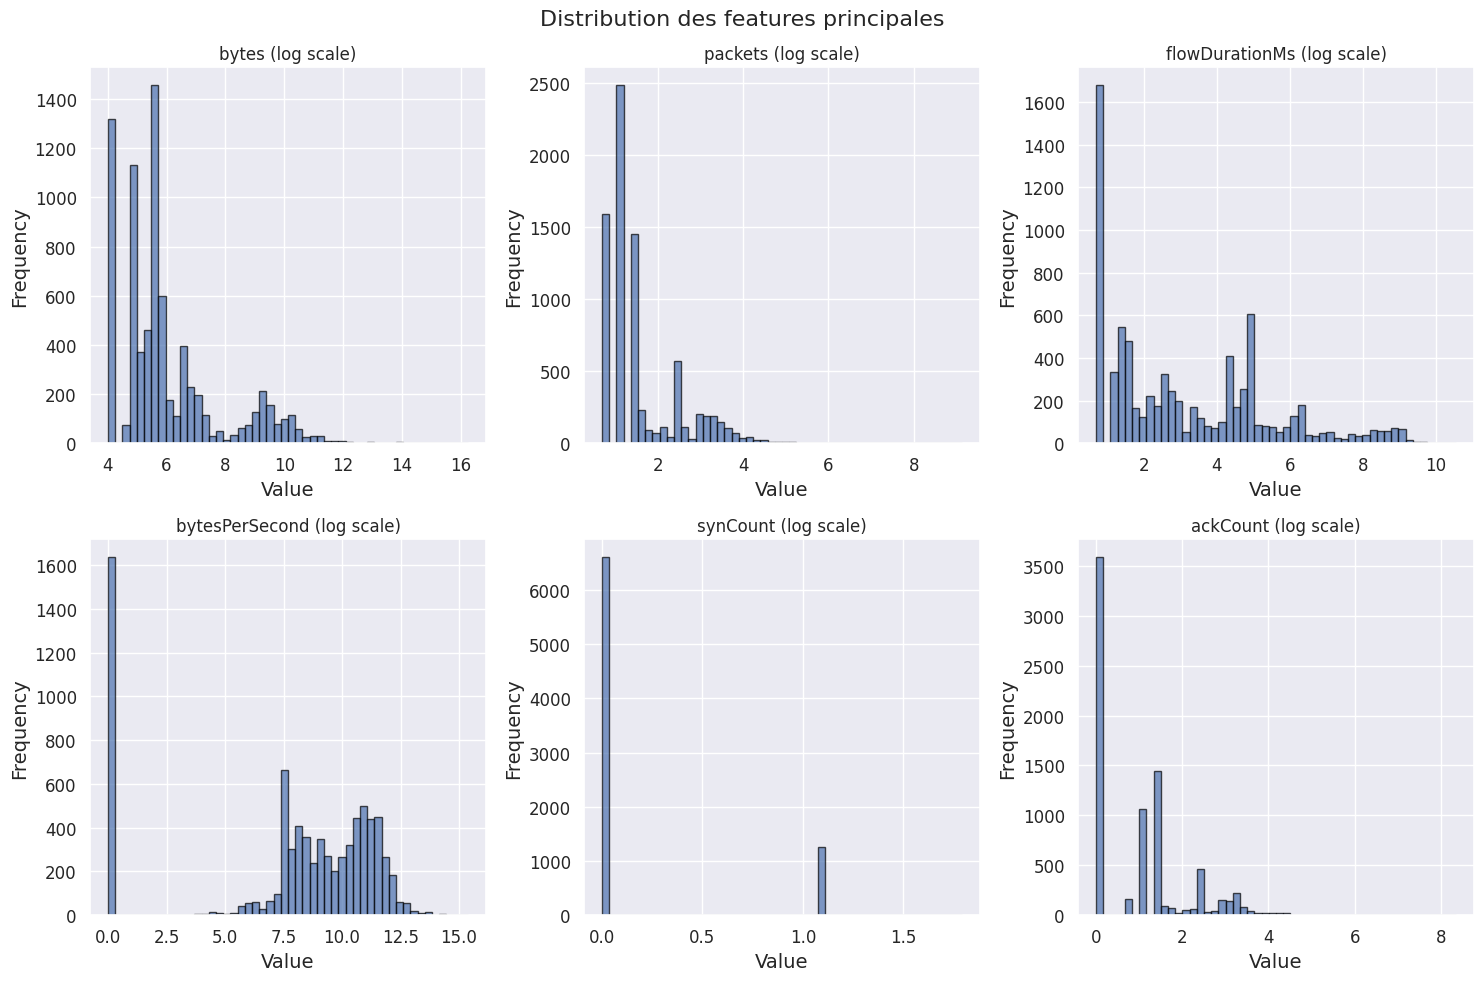

In [210]:
# Visualisation de quelques distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution des features principales', fontsize=16)

features_to_plot = ['bytes', 'packets', 'flowDurationMs', 
                    'bytesPerSecond', 'synCount', 'ackCount']

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    # Log transform pour meilleure visualisation
    data = np.log1p(train_processed[feature])
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'{feature} (log scale)')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [211]:
# 🔍 DEBUG : Analyse du test set
print("\n" + "="*80)
print("🔍 ANALYSE DU TEST SET")
print("="*80)

if 'riskLabel' in test_processed.columns:
    print("\n📊 Distribution riskLabel dans test :")
    print(test_processed['riskLabel'].value_counts())
    
if 'attackType' in test_processed.columns:
    print("\n📊 Distribution attackType dans test :")
    print(test_processed['attackType'].value_counts())

print(f"\n📊 Statistiques test vs train :")
print(f"   Train flows : {len(train_processed)}")
print(f"   Test flows  : {len(test_processed)}")
print(f"   Ratio       : {len(test_processed) / len(train_processed):.1f}x")

# Comparer les distributions
print(f"\n📊 Moyennes des features (Test vs Train) :")
for col in ['bytes', 'packets', 'flowDurationMs'][:3]:
    train_mean = train_processed[col].mean()
    test_mean = test_processed[col].mean()
    diff_pct = abs(test_mean - train_mean) / train_mean * 100
    print(f"   {col:20s} : Train={train_mean:>10.2f}  Test={test_mean:>10.2f}  Diff={diff_pct:>6.1f}%")


🔍 ANALYSE DU TEST SET

📊 Statistiques test vs train :
   Train flows : 7881
   Test flows  : 55512
   Ratio       : 7.0x

📊 Moyennes des features (Test vs Train) :
   bytes                : Train=   9648.81  Test=     54.83  Diff=  99.4%
   packets              : Train=     13.33  Test=      1.00  Diff=  92.5%
   flowDurationMs       : Train=    440.20  Test=   1904.00  Diff= 332.5%


## 5. FEATURE ENGINEERING & SCALING

In [212]:
X_train_raw = train_processed[ALL_FEATURES].copy()
X_test_raw = test_processed[ALL_FEATURES].copy()

y_train = None
y_train_encoded = None
print("\n⚠️ Pas de labels disponibles (mode non supervisé)")

y_test = None
y_test_encoded = None

print(f"\n📊 Features shape:")
print(f"   X_train: {X_train_raw.shape}")
print(f"   X_test: {X_test_raw.shape}")


⚠️ Pas de labels disponibles (mode non supervisé)

📊 Features shape:
   X_train: (7881, 38)
   X_test: (55512, 38)


In [213]:
# Log transformation des features (comme dans votre config)
log_cols = [
    'bytes', 'packets', 'durationMs', 'meanPacketLength',
    'bytesPerSecond', 'packetsPerSecond', 'totalBytesUpstream',
    'totalBytesDownstream', 'totalPacketsUpstream', 'totalPacketsDownstream',
    'flowDurationMs', 'interArrivalTimeMean', 'interArrivalTimeStdDev',
    'avgPacketIntervalMs'
]

X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

for col in log_cols:
    if col in X_train.columns:
        X_train[col] = np.log1p(X_train[col])
        X_test[col] = np.log1p(X_test[col])

print("✅ Log transformation appliquée")

✅ Log transformation appliquée


In [214]:
# Scaling avec StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir en DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=ALL_FEATURES)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=ALL_FEATURES)

print("✅ Scaling appliqué (mean=0, std=1)")
print(f"   Train mean: {X_train_scaled.mean():.6f}")
print(f"   Train std: {X_train_scaled.std():.6f}")

✅ Scaling appliqué (mean=0, std=1)
   Train mean: -0.000000
   Train std: 1.000000


## 6. FEATURE IMPORTANCE (Random Forest)

In [215]:
# Si on a des labels, calculer l'importance des features
if y_train_encoded is not None:
    print("\n🌲 Calcul de l'importance des features avec Random Forest...")
    rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rfc.fit(X_train_scaled, y_train_encoded)
    
    # Importance des features
    score = np.round(rfc.feature_importances_, 3)
    importances = pd.DataFrame({
        'feature': ALL_FEATURES,
        'importance': score
    })
    importances = importances.sort_values('importance', ascending=False)
    
    # Afficher top 15
    print("\n📊 Top 15 features les plus importantes:")
    print(importances.head(15).to_string(index=False))
    
    # Plot
    plt.figure(figsize=(12, 8))
    plt.barh(importances['feature'].head(20), importances['importance'].head(20))
    plt.xlabel('Importance')
    plt.title('Top 20 Features par Importance (Random Forest)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ Impossible de calculer l'importance : pas de labels")


⚠️ Impossible de calculer l'importance : pas de labels


## 7. RECURSIVE FEATURE ELIMINATION (optionnel)

In [216]:
# RFE pour sélectionner les meilleures features (si labels disponibles)
if y_train_encoded is not None:
    print("\n🔍 Recursive Feature Elimination (RFE)...")
    rfc = RandomForestClassifier(n_estimators=50, random_state=42)
    rfe = RFE(rfc, n_features_to_select=20)
    rfe = rfe.fit(X_train_scaled, y_train_encoded)
    
    feature_map = [(i, v) for i, v in zip(rfe.support_, ALL_FEATURES)]
    selected_features = [v for i, v in feature_map if i == True]
    
    print(f"\n✅ {len(selected_features)} features sélectionnées par RFE:")
    for feat in selected_features:
        print(f"   - {feat}")
else:
    selected_features = ALL_FEATURES
    print("\n⚠️ Utilisation de toutes les features (pas de RFE sans labels)")


⚠️ Utilisation de toutes les features (pas de RFE sans labels)


## 8. DATASET PARTITION (si supervisé)

In [217]:
# Si on a des labels, faire un split train/validation
if y_train_encoded is not None:
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_scaled, y_train_encoded, 
        train_size=0.70, 
        random_state=42,
        stratify=y_train_encoded
    )
    print(f"\n✅ Dataset split:")
    print(f"   Train: {X_tr.shape[0]} samples")
    print(f"   Val: {X_val.shape[0]} samples")
    print(f"   Test: {X_test_scaled.shape[0]} samples")
else:
    # Mode non supervisé
    X_tr = X_train_scaled
    y_tr = None
    X_val = None
    y_val = None
    print("\n⚠️ Mode non supervisé : pas de split train/val")


⚠️ Mode non supervisé : pas de split train/val


## 9. MODEL TRAINING - ISOLATION FOREST (Méthode recommandée pour anomalies)

In [218]:
print("\n🌳 Entraînement Isolation Forest (détection d'anomalies)...")

# 🔧 Testez différents seuils de contamination
contamination_value = 0.05  # Commencez par 5%

iso_forest = IsolationForest(
    n_estimators=300,
    max_samples='auto',
    contamination=contamination_value,
    random_state=42,
    n_jobs=-1
)

# Entraîner sur TOUTES les données (méthode non supervisée)
iso_forest.fit(X_train_scaled)

print("✅ Isolation Forest entraîné")

# Prédictions
train_predictions = iso_forest.predict(X_train_scaled)
test_predictions = iso_forest.predict(X_test_scaled)

# Scores de décision (plus négatif = plus anormal)
train_scores = iso_forest.decision_function(X_train_scaled)
test_scores = iso_forest.decision_function(X_test_scaled)

# 🔍 ANALYSE APPROFONDIE DES SCORES
print(f"\n📊 Analyse des scores :")
print(f"   Train - Min : {train_scores.min():.6f}")
print(f"   Train - Max : {train_scores.max():.6f}")
print(f"   Train - 1%  : {np.percentile(train_scores, 1):.6f} ← Seuil anomalie")
print(f"   Test  - Min : {test_scores.min():.6f}")
print(f"   Test  - Max : {test_scores.max():.6f}")

# Compter combien de test scores sont en dessous du seuil train
train_threshold = np.percentile(train_scores, 1)
test_below_threshold = (test_scores < train_threshold).sum()
print(f"\n   Test scores < seuil train : {test_below_threshold} ({test_below_threshold/len(test_scores)*100:.2f}%)")

# Statistiques
train_anomalies = (train_predictions == -1).sum()
test_anomalies = (test_predictions == -1).sum()

print(f"\n📊 Résultats Isolation Forest:")
print(f"   Train - Anomalies: {train_anomalies}/{len(train_predictions)} ({train_anomalies/len(train_predictions)*100:.2f}%)")
print(f"   Test - Anomalies: {test_anomalies}/{len(test_predictions)} ({test_anomalies/len(test_predictions)*100:.2f}%)")
print(f"   Score range: [{train_scores.min():.4f}, {train_scores.max():.4f}]")


🌳 Entraînement Isolation Forest (détection d'anomalies)...
✅ Isolation Forest entraîné

📊 Analyse des scores :
   Train - Min : -0.142837
   Train - Max : 0.177212
   Train - 1%  : -0.058574 ← Seuil anomalie
   Test  - Min : -0.115501
   Test  - Max : 0.166932

   Test scores < seuil train : 5 (0.01%)

📊 Résultats Isolation Forest:
   Train - Anomalies: 378/7881 (4.80%)
   Test - Anomalies: 12/55512 (0.02%)
   Score range: [-0.1428, 0.1772]


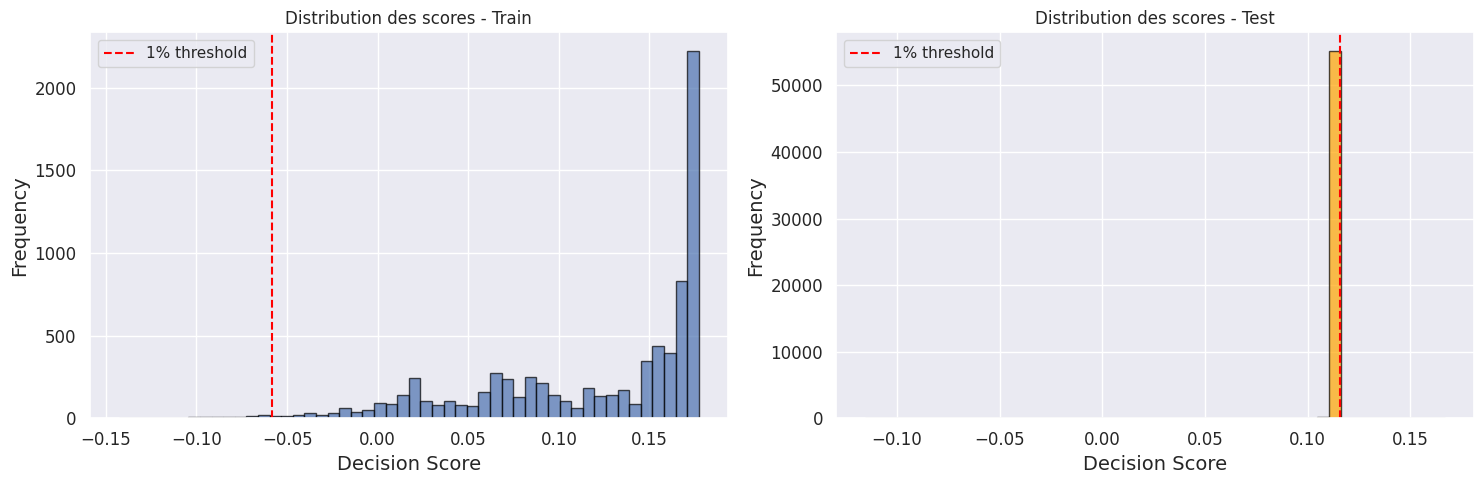

In [219]:
# Visualisation de la distribution des scores
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(train_scores, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(np.percentile(train_scores, 1), color='red', linestyle='--', label='1% threshold')
axes[0].set_title('Distribution des scores - Train')
axes[0].set_xlabel('Decision Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(test_scores, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(np.percentile(test_scores, 1), color='red', linestyle='--', label='1% threshold')
axes[1].set_title('Distribution des scores - Test')
axes[1].set_xlabel('Decision Score')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. SUPERVISED MODELS (si labels disponibles)

In [220]:
if y_train_encoded is not None:
    print("\n🤖 Entraînement des modèles supervisés...")
    
    # KNN
    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn.fit(X_tr, y_tr)
    
    # Logistic Regression
    lgr = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)
    lgr.fit(X_tr, y_tr)
    
    # Naive Bayes
    bnb = BernoulliNB()
    bnb.fit(X_tr, y_tr)
    
    # Decision Tree
    dtc = tree.DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=10)
    dtc.fit(X_tr, y_tr)
    
    # Random Forest
    rfc_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rfc_model.fit(X_tr, y_tr)
    
    print("✅ 5 modèles entraînés")
    
    models = [
        ('KNN', knn),
        ('Logistic Regression', lgr),
        ('Naive Bayes', bnb),
        ('Decision Tree', dtc),
        ('Random Forest', rfc_model)
    ]
else:
    print("\n⚠️ Mode non supervisé : pas d'entraînement de modèles supervisés")
    models = []


⚠️ Mode non supervisé : pas d'entraînement de modèles supervisés


## 11. MODEL EVALUATION

In [221]:
if len(models) > 0 and y_val is not None:
    print("\n" + "="*80)
    print("📊 ÉVALUATION DES MODÈLES SUR VALIDATION SET")
    print("="*80)
    
    results = []
    
    for name, model in models:
        # Prédictions
        y_pred = model.predict(X_val)
        
        # Métriques
        accuracy = metrics.accuracy_score(y_val, y_pred)
        precision = metrics.precision_score(y_val, y_pred, average='weighted', zero_division=0)
        recall = metrics.recall_score(y_val, y_pred, average='weighted', zero_division=0)
        f1 = metrics.f1_score(y_val, y_pred, average='weighted', zero_division=0)
        
        results.append({
            'Model': name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        })
        
        print(f"\n{'='*80}")
        print(f"{name}")
        print(f"{'='*80}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"\nClassification Report:")
        print(metrics.classification_report(y_val, y_pred, target_names=le.classes_, zero_division=0))
        print(f"\nConfusion Matrix:")
        print(metrics.confusion_matrix(y_val, y_pred))
    
    # Comparaison des modèles
    results_df = pd.DataFrame(results)
    print(f"\n{'='*80}")
    print("📊 COMPARAISON DES MODÈLES")
    print(f"{'='*80}")
    print(results_df.to_string(index=False))
    
    # Meilleur modèle
    best_model = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
    print(f"\n🏆 Meilleur modèle: {best_model}")

## 12. TEST SET EVALUATION

In [222]:
if len(models) > 0 and y_test_encoded is not None:
    print("\n" + "="*80)
    print("📊 ÉVALUATION SUR TEST SET")
    print("="*80)
    
    for name, model in models:
        y_pred = model.predict(X_test_scaled)
        accuracy = metrics.accuracy_score(y_test_encoded, y_pred)
        
        print(f"\n{name}:")
        print(f"  Accuracy: {accuracy:.4f}")
        print(metrics.classification_report(y_test_encoded, y_pred, 
                                           target_names=le.classes_, zero_division=0))

## 13. SAVE MODELS

In [223]:
# Sauvegarder Isolation Forest (méthode principale)
print("\n💾 Sauvegarde des modèles...")

# Config de preprocessing
config = {
    'BASE_FEATURES': BASE_FEATURES,
    'DERIVED_FEATURES': DERIVED_FEATURES,
    'FEATURES': ALL_FEATURES,
    'log_cols': log_cols,
    'cols_to_replace': ['flowDurationMs', 'totalPacketsUpstream', 
                        'totalPacketsDownstream', 'interArrivalTimeMean'],
    'scaler': scaler
}

with open('preprocessing_config.pkl', 'wb') as f:
    pickle.dump(config, f)
print("   ✅ preprocessing_config.pkl")

# Isolation Forest
with open('IDS_Stage1_Detector.pkl', 'wb') as f:
    pickle.dump(iso_forest, f)
print("   ✅ IDS_Stage1_Detector.pkl (Isolation Forest)")

# Sauvegarder le meilleur modèle supervisé si disponible
if len(models) > 0:
    best_model_obj = [m for n, m in models if n == best_model][0]
    with open(f'IDS_Stage1_{best_model.replace(" ", "_")}.pkl', 'wb') as f:
        pickle.dump(best_model_obj, f)
    print(f"   ✅ IDS_Stage1_{best_model.replace(' ', '_')}.pkl")

print("\n✅ Tous les modèles sont sauvegardés!")


💾 Sauvegarde des modèles...
   ✅ preprocessing_config.pkl
   ✅ IDS_Stage1_Detector.pkl (Isolation Forest)

✅ Tous les modèles sont sauvegardés!


## 14. EXPORT RESULTS

In [224]:
# Ajouter les prédictions au test set
test_results = test_processed.copy()
test_results['iso_forest_prediction'] = test_predictions
test_results['iso_forest_score'] = test_scores
test_results['iso_forest_label'] = test_predictions
test_results['iso_forest_label'] = test_results['iso_forest_label'].map(
    {-1: 'ANOMALY', 1: 'NORMAL'}
)

# Exporter
output_file = TEST_PATH.replace('.csv', '_predictions.csv')
test_results.to_csv(output_file, index=False)
print(f"\n💾 Résultats exportés: {output_file}")

# Top anomalies
anomalies = test_results[test_results['iso_forest_label'] == 'ANOMALY'].sort_values('iso_forest_score')
if len(anomalies) > 0:
    print(f"\n🚨 Top 10 anomalies détectées:")
    cols = ['srcIp', 'dstIp', 'protocol', 'bytes', 'packets', 'flowDurationMs', 'iso_forest_score']
    available_cols = [c for c in cols if c in anomalies.columns]
    print(anomalies[available_cols].head(10).to_string(index=False))


💾 Résultats exportés: data/vertx_flows_test2_predictions.csv

🚨 Top 10 anomalies détectées:
              protocol  bytes  packets  flowDurationMs  iso_forest_score
                   TCP   7563        4      61393730.0         -0.115501
                   TCP   7915        3       4836272.0         -0.091545
                  IGMP    120        2       5179973.0         -0.070539
                  IGMP    120        2       5687062.0         -0.070539
IPv6 Hop-by-Hop Option    180        2      17516740.0         -0.068820
                   UDP    684        2       7031141.0         -0.050476
                   TCP    204        2        502163.0         -0.046471
                   TCP    266        2        120105.0         -0.041617
                   TCP    114        2       3371911.0         -0.039749
                   TCP   7354        1             1.0         -0.031502


## ✅ RÉSUMÉ FINAL

In [225]:
print("\n" + "="*80)
print("🎉 PIPELINE COMPLET TERMINÉ")
print("="*80)
print(f"\n📊 Données:")
print(f"   - Train: {len(train_processed)} flows")
print(f"   - Test: {len(test_processed)} flows")
print(f"   - Features: {len(ALL_FEATURES)}")
print(f"\n🌳 Isolation Forest:")
print(f"   - Anomalies train: {train_anomalies} ({train_anomalies/len(train_predictions)*100:.2f}%)")
print(f"   - Anomalies test: {test_anomalies} ({test_anomalies/len(test_predictions)*100:.2f}%)")
if len(models) > 0:
    print(f"\n🤖 Modèles supervisés:")
    print(f"   - Meilleur modèle: {best_model}")
    print(f"   - F1-Score: {results_df.loc[results_df['Model']==best_model, 'F1-Score'].values[0]:.4f}")
print("\n💾 Fichiers générés:")
print("   - preprocessing_config.pkl")
print("   - IDS_Stage1_Detector.pkl")
print(f"   - {output_file}")
print("\n✅ Utilisez IDS_stage1_test.py pour tester le modèle!")
print("="*80)


🎉 PIPELINE COMPLET TERMINÉ

📊 Données:
   - Train: 7881 flows
   - Test: 55512 flows
   - Features: 38

🌳 Isolation Forest:
   - Anomalies train: 378 (4.80%)
   - Anomalies test: 12 (0.02%)

💾 Fichiers générés:
   - preprocessing_config.pkl
   - IDS_Stage1_Detector.pkl
   - data/vertx_flows_test2_predictions.csv

✅ Utilisez IDS_stage1_test.py pour tester le modèle!
